# **Diabetes prediction**

# Pregled skupa podataka

Cilj projekta je razvoj i evaluacija modela mašinskog učenja za predviđanje pojave dijabetesa kod pacijenata na osnovu njihovih demografskih karakteristika, zdravstvenih parametara i životnih navika.

Kao dataset je korišćen skup podataka *diabetes_prediction_dataset.csv* preuzet sa Kaggle-a.

U dataset-u se nalaze oko 100000 primera sa 9 atributa koji opisuju zdravstveno stanje i životne navike ljudi. Dataset sadrži kombinaciju numeričkih, kategorijskih i binarnih atributa, pri čemu je ciljna promenljiva Diabetes binarnog tipa i označava prisustvo ili odsustvo dijabetesa kod pacijenta.

| Karakteristika | Tip podataka | Opis |
|---------------|--------------------|-----|
| Gender | Kategorijski |Pol pacijenta |
| Age | Numerički| Starost pacijenta u godinama |
| Hypertension | Binarni (0/1) | Visok krvni pritisak (0 = ne, 1 = da) |
| Heart Disease | Binarni (0/1) | Srčane bolesti (0 = ne, 1 = da) |
| Smoking History | Kategorijski | Istorija pušenja |
| BMI | Numerički | Indeks telesne mase |
| HbA1c Level | Numerički | Prosečan nivo šećera u krvi |
| Blood Glucose Level | Numerički | Trenutni nivo glukoze u krvi |
| Diabetes | Binarni (0/1) | Ciljna promenljiva (1 = prisustvo dijabetesa, 0 = nema dijabetesa)|

### Dodatne biblioteke
Pored standardnih biblioteka, koristi se i **LightGBM**. 

In [1]:
%pip install lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.


## EDA

U okviru eksplorativne analize podataka (EDA) izvršena je osnovna analiza strukture skupa podataka, provera nedostajućih vrednosti, uklanjanje duplikata i izračunavanje deskriptivnih statističkih mera.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score, classification_report)

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [4]:
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Nema nedostajućih vrednosti.

In [7]:
print('Broj duplikata u dataset-u: ', df.duplicated().sum())

Broj duplikata u dataset-u:  3854


In [8]:
# uklanjanje duplikata
df = df.drop_duplicates()
print('Dimenzije podataka nakon uklanjanja duplikata:', df.shape)

Dimenzije podataka nakon uklanjanja duplikata: (96146, 9)


In [9]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


Nakon osnovne analize i čišćenja podataka, u nastavku je sprovedena vizuelna eksplorativna analiza radi detaljnijeg uvida u raspodelu i međusobne odnose atributa.

## Analiza ciljne promenljive

In [10]:
df['diabetes'].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

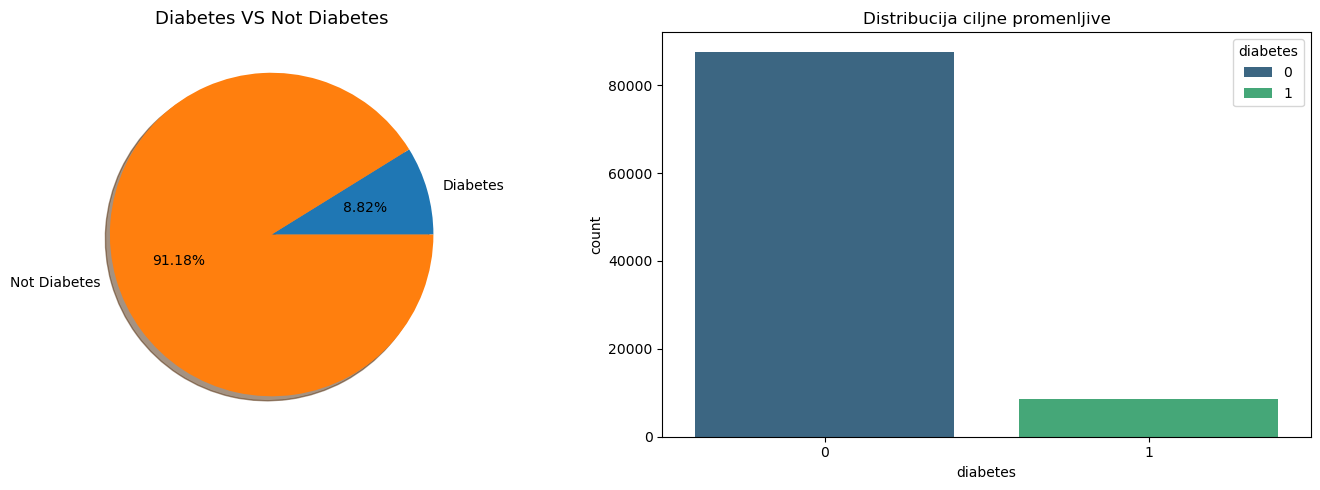

In [11]:
diabetes_count = df['diabetes'].value_counts()[1]
not_diabetes_count = df['diabetes'].value_counts()[0]
sizes = [diabetes_count, not_diabetes_count]
labels = ['Diabetes', 'Not Diabetes']
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].pie(sizes, labels=labels, shadow=True, autopct='%1.2f%%')
ax[0].set_title('Diabetes VS Not Diabetes', size=13)

sns.countplot(x='diabetes', hue='diabetes', data=df, palette='viridis', ax=ax[1])
ax[1].set_title('Distribucija ciljne promenljive')
plt.tight_layout()
plt.show()

Na grafiku (pita i countplot) prikazana je raspodela ciljne promenljive *diabetes*. Analiza pokazuje da postoji izražen **disbalans** klasa — značajno je više pacijenata bez dijabetesa (klasa 0) nego onih sa dijabetesom (klasa 1).

Ovaj disbalans može uticati na performanse modela, posebno na *recall* za manjinsku klasu. Najpre gradimo polazni (baseline) model na neuravnoteženim podacima, a tek potom primenjujemo tehnike balansiranja kako bismo izmerili njihov stvarni doprinos.

## Histogrami

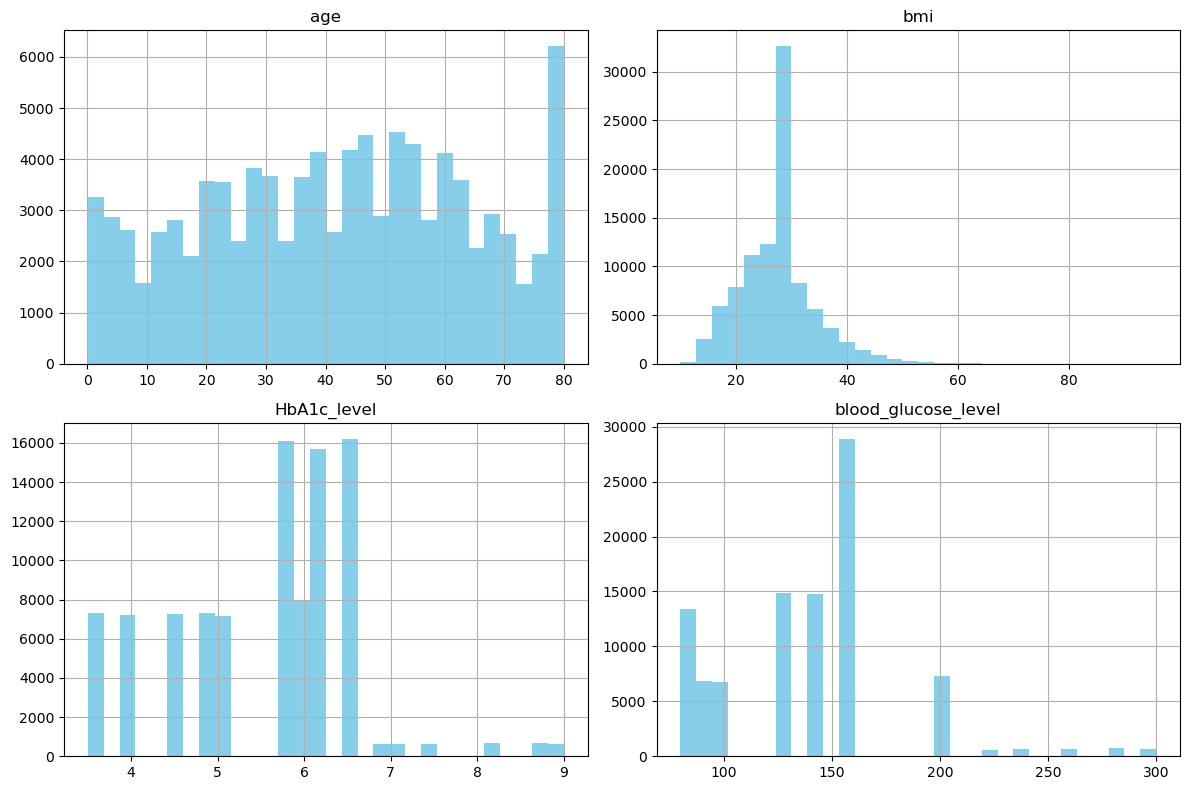

In [12]:
numeric_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
df[numeric_features].hist(bins=30, figsize=(12, 8), color='skyblue')

plt.tight_layout()
plt.show()

Histogrami prikazuju raspodelu (broj pacijenata po opsezima vrednosti) za četiri numerička atributa. Starost ispitanika (*age*) je pretežno koncentrisana u srednjim godinama, dok *BMI* pokazuje blagu desnu asimetriju, što ukazuje na prisustvo pacijenata sa povišenom telesnom masom. Raspodele *HbA1c* nivoa i *nivoa glukoze u krvi* imaju manji broj visokih vrednosti, što je u skladu sa postojanjem disbalansa u ciljnoj promenljivoj. Ovi uvidi su značajni za dalje korake predobrade i izgradnje modela.

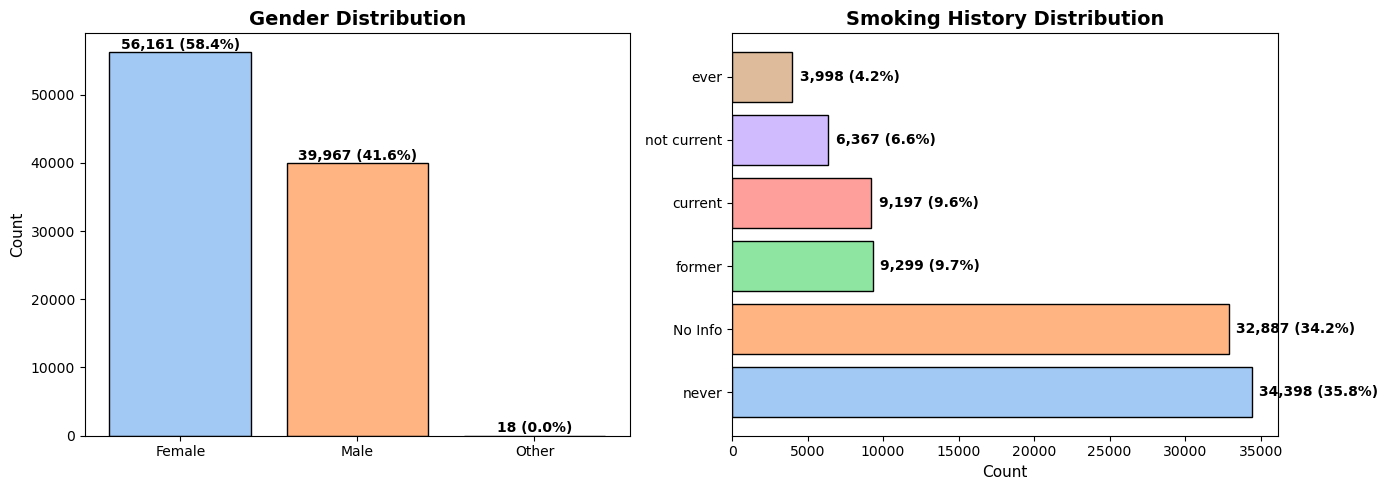

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=sns.color_palette('pastel'), edgecolor='black')
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 500, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

smoking_counts = df['smoking_history'].value_counts()
axes[1].barh(smoking_counts.index, smoking_counts.values, color=sns.color_palette('pastel', len(smoking_counts)), edgecolor='black')
axes[1].set_title('Smoking History Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
for i, v in enumerate(smoking_counts.values):
    axes[1].text(v + 500, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Grafik prikazuje raspodelu kategorijskih atributa. Skup podataka je relativno uravnotežen po polu (levi grafik). S obzirom da je kategorija *Other* izuzetno slabo zastupljena, ona se izostavlja iz analize, a pol se konvertuje u binarnu promenljivu. Distribucija istorije pušenja (desni grafik) pokazuje da najveći deo ispitanika nikada nije pušio ili pripada kategoriji *No Info*, dok su ostale kategorije manje zastupljene.

In [14]:
df = df[df.gender != 'Other']
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,never,25.19,6.6,140,0
1,0,54.0,0,0,No Info,27.32,6.6,80,0
2,1,28.0,0,0,never,27.32,5.7,158,0
3,0,36.0,0,0,current,23.45,5.0,155,0
4,1,76.0,1,1,current,20.14,4.8,155,0


## Boxplot analiza (detekcija outliera)

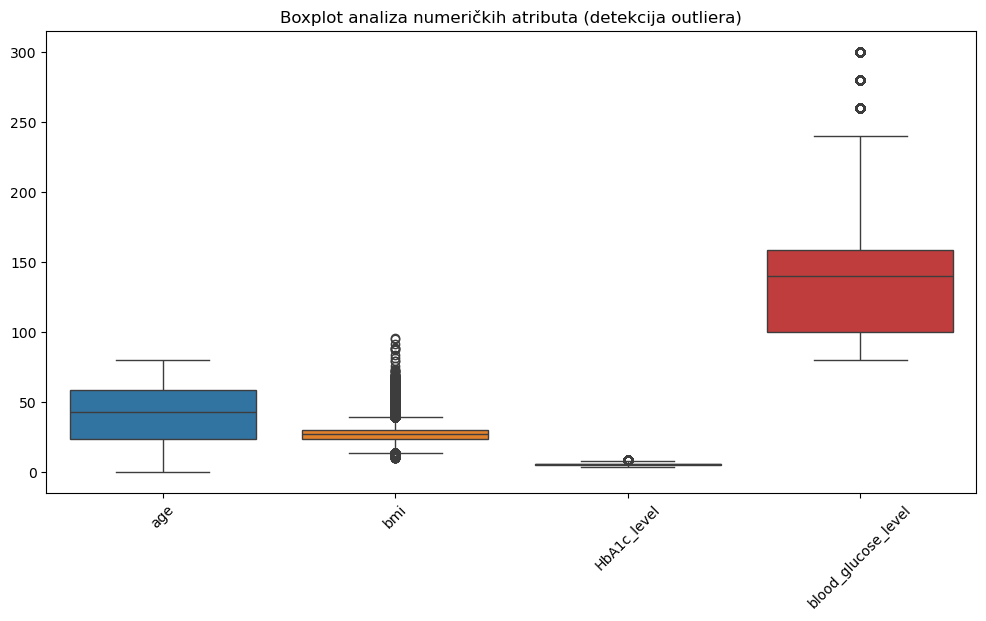

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=45)
plt.title('Boxplot analiza numeričkih atributa (detekcija outliera)')
plt.show()

Boxplot prikazuje raspodelu numeričkih atributa i tačke van „brkova" grafika predstavljaju ekstremne vrednosti (outliere). Uočen je određeni broj outliera, najizraženijih kod atributa *BMI*, *HbA1c level* i *blood glucose level*.

Prisustvo outliera je očekivano u medicinskim skupovima podataka i ne mora predstavljati greške u podacima, već može ukazivati na klinički relevantne slučajeve. Zbog toga se outlieri **ne uklanjaju i ne tretiraju u ovoj fazi**. Njihov tretman (capping) primenjujemo tek **nakon izgradnje polaznog modela**, kako bismo mogli da izmerimo da li taj postupak zaista poboljšava rezultate.

## Pair plot analiza

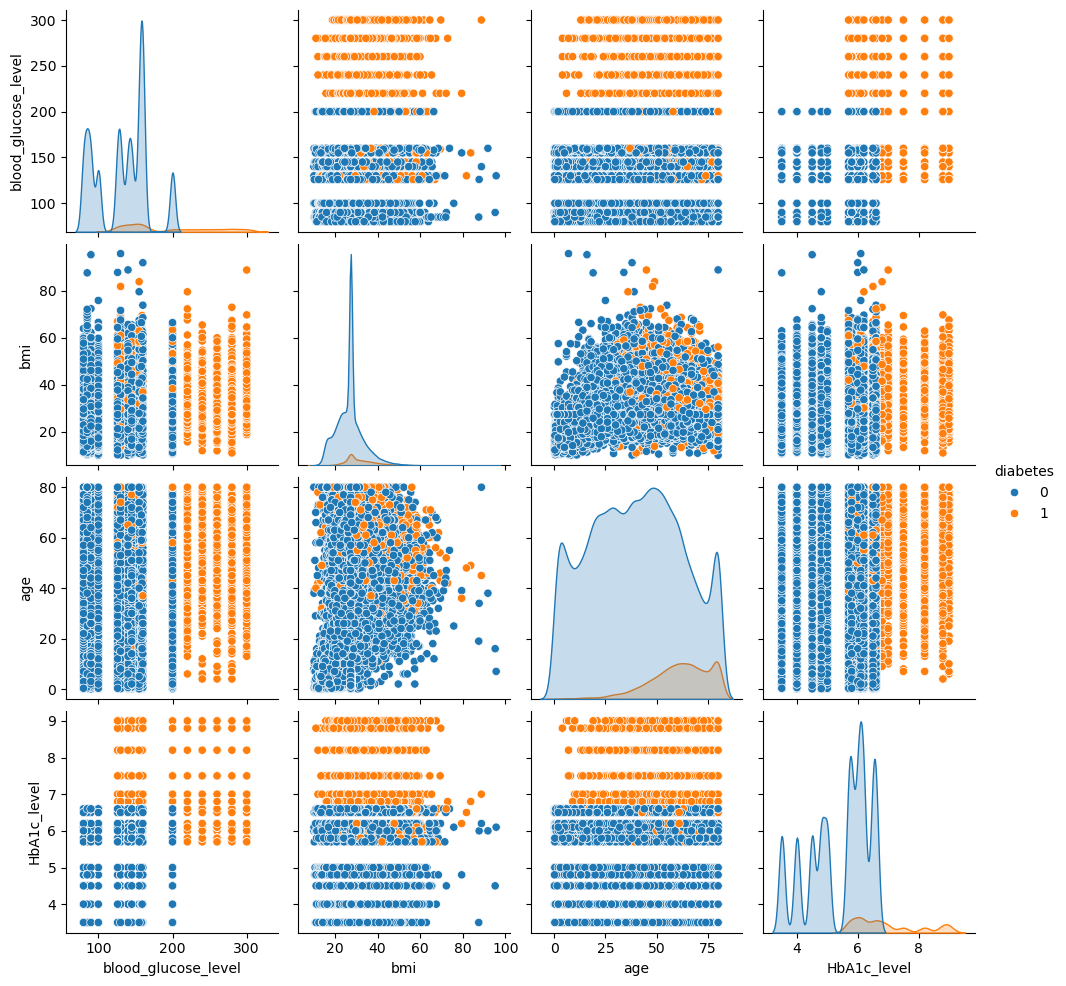

In [16]:
sns.pairplot(df[['blood_glucose_level', 'bmi', 'age', 'HbA1c_level', 'diabetes']], hue='diabetes')
plt.show()

###  Detaljna analiza Pair Plot-a

**Pair plot** (grafik parnih odnosa) nam omogućava da vizualizujemo raspodelu pojedinačnih numeričkih karakteristika (na dijagonali) i njihove međusobne korelacije i odnose (van dijagonale), podeljene prema ciljnoj klasi `diabetes` (plava boja = bez dijabetesa, narandžasta boja = sa dijabetesom).


####  Ključna zapažanja 

1. **Glavni prediktori (Visoka diskriminativna moć):**
   * **`blood_glucose_level` (Nivo glukoze u krvi)** i **`HbA1c_level`**: 
     * Pogledom na njihove pojedinačne distribucije (dijagonala) i međusobni odnos (skater plot), jasno se uočava da se narandžaste tačke (pacijenti sa dijabetesom) grupišu na znatno višim vrednostima.
     * Pacijenti sa vrednostima `HbA1c_level` iznad $6.5$ i `blood_glucose_level` preko $200$ gotovo bez izuzetka pripadaju klasi sa dijabetesom. Ova dva parametra predstavljaju najjače linearne i nelinearne separatore u skupu podataka.

2. **Sekundarni prediktori (Preklapanje i slabija samostalna predikcija):**
   * **`age` (Starost)** i **`bmi` (Indeks telesne mase)**:
     * Njihove raspodele na dijagonali pokazuju izuzetno veliko preklapanje između klasa. 
     * Iako starije osobe i osobe sa višim BMI statistički imaju veću šansu da dobiju dijabetes (narandžasta boja postaje gušća na desnoj strani grafika), sami po sebi ovi atributi ne mogu precizno razdvojiti klase jer postoji ogroman broj plavih tačaka (zdravih pacijenata) sa identičnim godinama i visokim BMI-jem.

3. **Korelacije i šabloni:**
   * Vidimo horizontalno i vertikalno "pruganje" na nekim grafikonima (npr. kod `HbA1c_level` i `blood_glucose_level`). To nam ukazuje na to da su ove vrednosti u skupu podataka često zabeležene kao diskretne ili zaokružene vrednosti, a ne potpuno kontinualne.


### Analiza binarnih kliničkih indikatora

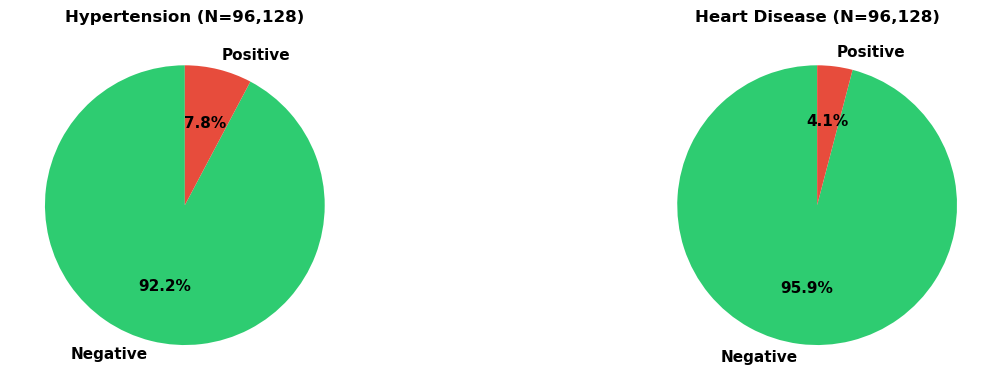

In [17]:
binary_features = ['hypertension', 'heart_disease']
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for idx, feature in enumerate(binary_features):
    counts = df[feature].value_counts()
    colors = ['#2ecc71', '#e74c3c']
    axes[idx].pie(counts, labels=['Negative', 'Positive'], autopct='%1.1f%%',
                  colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[idx].set_title(f'{feature.replace("_", " ").title()} (N={len(df):,})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Grafici prikazuju udeo pozitivnih i negativnih vrednosti za binarne kliničke indikatore. Većina ispitanika nema hipertenziju ni srčane bolesti. Uočeni disbalans i kod ovih atributa dodatno naglašava potrebu za pažljivim izborom evaluacionih metrika tokom modelovanja (ne oslanjati se samo na tačnost).

## Korelaciona matrica

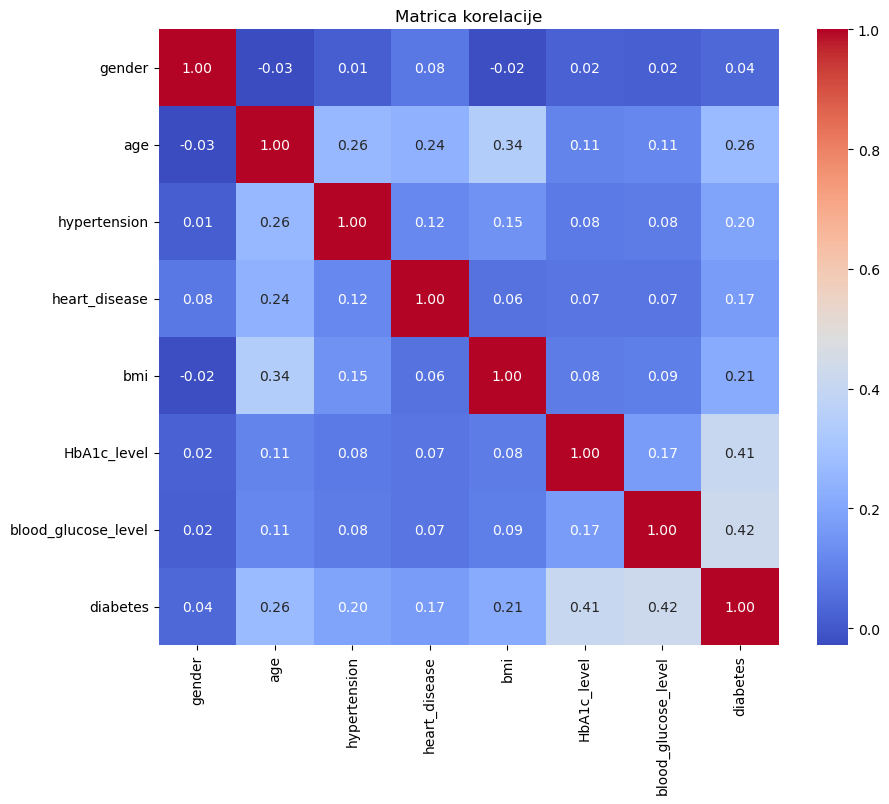

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrica korelacije')
plt.show()

Toplotna mapa prikazuje Pirsonove koeficijente korelacije između atributa (vrednosti od -1 do 1). Najjače pozitivne korelacije sa ciljnom promenljivom *diabetes* imaju *HbA1c nivo* i *nivo glukoze u krvi*. Korelacije sa demografskim i binarnim indikatorima (age, hypertension, heart_disease) su slabije, ali i dalje informativne — što znači da dijabetes zavisi od kombinacije više faktora, a ne od jednog pojedinačnog atributa.

# **Priprema podataka za polazni model**

Radimo **minimalnu pripremu** (kodiranje kategorijskih promenljivih i podelu na trening/test skup) kako bismo što pre dobili polazni model. Tretman outliera i balansiranje klasa slede tek nakon toga.

## Kodiranje podataka

Promenljiva *smoking_history* sadrži kategoriju *No Info*. Najpre proveravamo da li je dostupnost te informacije povezana sa ciljnom promenljivom.

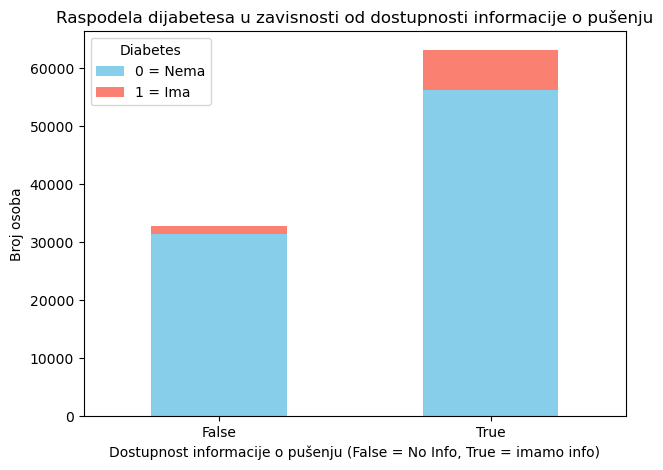

In [19]:
df['has_smoking_info'] = df['smoking_history'] != 'No Info'
info_counts = df.groupby(['has_smoking_info', 'diabetes']).size().unstack(fill_value=0)

info_counts.plot(kind='bar', stacked=True, figsize=(7, 5), color=['skyblue', 'salmon'])
plt.title('Raspodela dijabetesa u zavisnosti od dostupnosti informacije o pušenju')
plt.xlabel('Dostupnost informacije o pušenju (False = No Info, True = imamo info)')
plt.ylabel('Broj osoba')
plt.legend(title='Diabetes', labels=['0 = Nema', '1 = Ima'])
plt.xticks(rotation=0)
plt.show()

In [20]:
def simplify_smoking(status):
    if status in ['never', 'No Info']:
        return 0  # Nizak rizik
    else:
        return 1  # Povišen rizik (pušači i bivši pušači)

df['smoking_history'] = df['smoking_history'].apply(simplify_smoking)
if 'has_smoking_info' in df.columns:
    df = df.drop('has_smoking_info', axis=1)

print(df['smoking_history'].value_counts())
df.head()

smoking_history
0    67276
1    28852
Name: count, dtype: int64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,0,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


Promenljiva *smoking_history* je inicijalno sadržala više kategorija (never, current, former, ever, not current i No Info). Analizom je uočeno da kategorija *No Info* nije nasumično raspoređena, već je dominantno prisutna kod ispitanika bez dijabetesa, što može dovesti do pristrasnosti modela. Zbog toga je izvršena pojednostavljena rekategorizacija u binarnu formu, u skladu sa kliničkom interpretacijom rizika:

- vrednost **0** označava ispitanike koji nikada nisu pušili ili za koje nema informacija (never, No Info) — grupa sa nižim rizikom,
- vrednost **1** obuhvata sve ispitanike sa istorijom pušenja (current, former, ever, not current) — grupa sa povišenim rizikom.

Ovakva transformacija smanjuje šum u podacima, pojednostavljuje model i omogućava algoritmu da se fokusira na klinički relevantnu informaciju umesto na administrativne razlike u dostupnosti podataka.

## **Podela na trening i test skup**

In [21]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [22]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(df.shape)
print('Training set shape:', X_train_raw.shape)
print('Testing set shape:', X_test_raw.shape)
X_train_raw.head()

(96128, 9)
Training set shape: (76902, 8)
Testing set shape: (19226, 8)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
12312,0,22.0,0,0,0,24.12,6.1,100
51981,0,69.0,0,1,1,28.45,9.0,260
62671,1,31.0,0,0,0,20.67,6.6,200
33823,1,59.0,0,0,0,27.16,8.2,160
44586,0,24.0,0,0,0,22.65,6.2,140


Numeričke atribute standardizujemo (StandardScaler), jer su mnogi modeli (posebno linearni) osetljivi na razmeru vrednosti. Skaler se **uči isključivo na trening skupu**, a zatim primenjuje na test skup, čime se izbegava curenje informacija (data leakage).

In [23]:
scaler_base = StandardScaler()
X_train_base = X_train_raw.copy()
X_test_base = X_test_raw.copy()
X_train_base[numeric_features] = scaler_base.fit_transform(X_train_raw[numeric_features])
X_test_base[numeric_features] = scaler_base.transform(X_test_raw[numeric_features])

# Polazni (baseline) model

Pre bilo kakvog tretmana outliera ili balansiranja, gradimo jednostavan polazni model — **logističku regresiju**. On služi kao referentna tačka u odnosu na koju merimo doprinos svih narednih koraka.

Funkcija `evaluate_model` za dati model računa optimalni prag odlučivanja (na osnovu maksimalnog F1), ispisuje ključne metrike (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC) i prikazuje tri grafika: matricu konfuzije, ROC krivu i Precision-Recall krivu.

In [24]:
def evaluate_model(model, X_test_data, y_test_true, name):

    y_probs = model.predict_proba(X_test_data)[:, 1]

    precision_pts, recall_pts, thresholds = precision_recall_curve(y_test_true, y_probs)
    f1_scores = 2 * (precision_pts * recall_pts) / (precision_pts + recall_pts + 1e-9)

    best_idx = np.argmax(f1_scores)
    if best_idx >= len(thresholds):
        best_idx = len(thresholds) - 1
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f'\n{name}')
    print(f'Najbolji threshold (max F1): {best_threshold:.4f}')
    print(f'Najbolji F1 na tom threshold-u: {best_f1:.4f}')

    y_pred = (y_probs >= best_threshold).astype(int)

    metrics = {
        'Accuracy': accuracy_score(y_test_true, y_pred),
        'Precision': precision_score(y_test_true, y_pred),
        'Recall': recall_score(y_test_true, y_pred),
        'F1': f1_score(y_test_true, y_pred),
        'ROC-AUC': roc_auc_score(y_test_true, y_probs),
        'PR-AUC': average_precision_score(y_test_true, y_probs)
    }

    print(f'\n{name} Results')
    for key, value in metrics.items():
        print(f'{key}: {value:.4f}')

    if hasattr(model, 'coef_'):
        importance_values = model.coef_[0]
        label = 'Coefficient'
    elif hasattr(model, 'feature_importances_'):
        importance_values = model.feature_importances_
        label = 'Importance'
    else:
        importance_values = None

    if importance_values is not None:
        importance_df = pd.DataFrame({
            'Feature': X_test_data.columns,
            label: importance_values
        }).sort_values(label, ascending=False)
        print(f'\n--- RANG LISTA ATRIBUTA ({name}) ---')
        print(importance_df.head(10))

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_test_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0])
    ax[0].set_title(f'Confusion Matrix: {name}')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_test_true, y_probs)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_title('ROC Curve')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend(loc='lower right')

    precision_pts, recall_pts, _ = precision_recall_curve(y_test_true, y_probs)
    avg_prec = average_precision_score(y_test_true, y_probs)
    ax[2].plot(recall_pts, precision_pts, color='green', lw=2, label=f'Avg Precision = {avg_prec:.2f}')
    ax[2].set_title('Precision-Recall Curve')
    ax[2].set_xlabel('Recall')
    ax[2].set_ylabel('Precision')
    ax[2].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    return metrics, best_threshold

## Logistička regresija — baseline


Baseline - Logistička regresija
Najbolji threshold (max F1): 0.4576
Najbolji F1 na tom threshold-u: 0.7299

Baseline - Logistička regresija Results
Accuracy: 0.9576
Precision: 0.8335
Recall: 0.6492
F1: 0.7299
ROC-AUC: 0.9592
PR-AUC: 0.8123

--- RANG LISTA ATRIBUTA (Baseline - Logistička regresija) ---
               Feature  Coefficient
6          HbA1c_level     2.498124
7  blood_glucose_level     1.366032
1                  age     1.075453
2         hypertension     0.794897
3        heart_disease     0.679407
5                  bmi     0.611427
0               gender     0.289999
4      smoking_history     0.228673


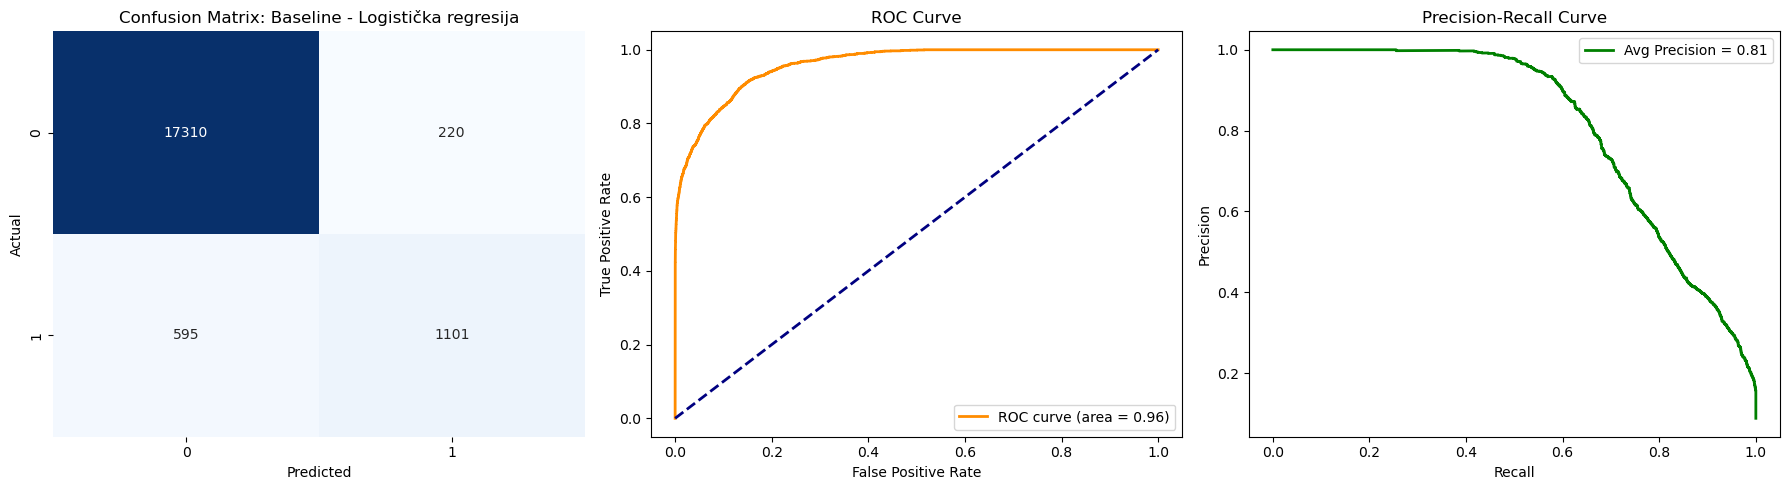

In [25]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_base, y_train)

baseline_metrics, baseline_thr = evaluate_model(log_reg, X_test_base, y_test, 'Baseline - Logistička regresija')

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_base, y_train, cv=cv, scoring='f1')
print(f'Baseline F1 (5-fold CV): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print('F1 po foldovima:', np.round(cv_scores, 4))

Baseline F1 (5-fold CV): 0.7284 +/- 0.0066
F1 po foldovima: [0.7242 0.7414 0.7275 0.7253 0.7236]


Polazni model postiže visoku *tačnost*, ali **nizak recall** za klasu pacijenata sa dijabetesom — očekivana posledica disbalansa klasa (model „preferira" većinsku klasu). Stratifikovana 5-struka kros-validacija potvrđuje da je F1 nizak i stabilan. Ova vrednost je referentna tačka koju u nastavku pokušavamo da poboljšamo tretmanom outliera i balansiranjem klasa.

# Poboljšanje modela: tretman outliera i balansiranje

Sada, kada imamo polazni model, primenjujemo dve tehnike i merimo njihov efekat: (1) ograničavanje ekstremnih vrednosti (capping) i (2) balansiranje klasa (SMOTETomek).

## Ograničavanje (capping) outliera

age: detektovano 0 outliera u trening skupu
bmi: detektovano 4236 outliera u trening skupu
HbA1c_level: detektovano 1045 outliera u trening skupu
blood_glucose_level: detektovano 1603 outliera u trening skupu


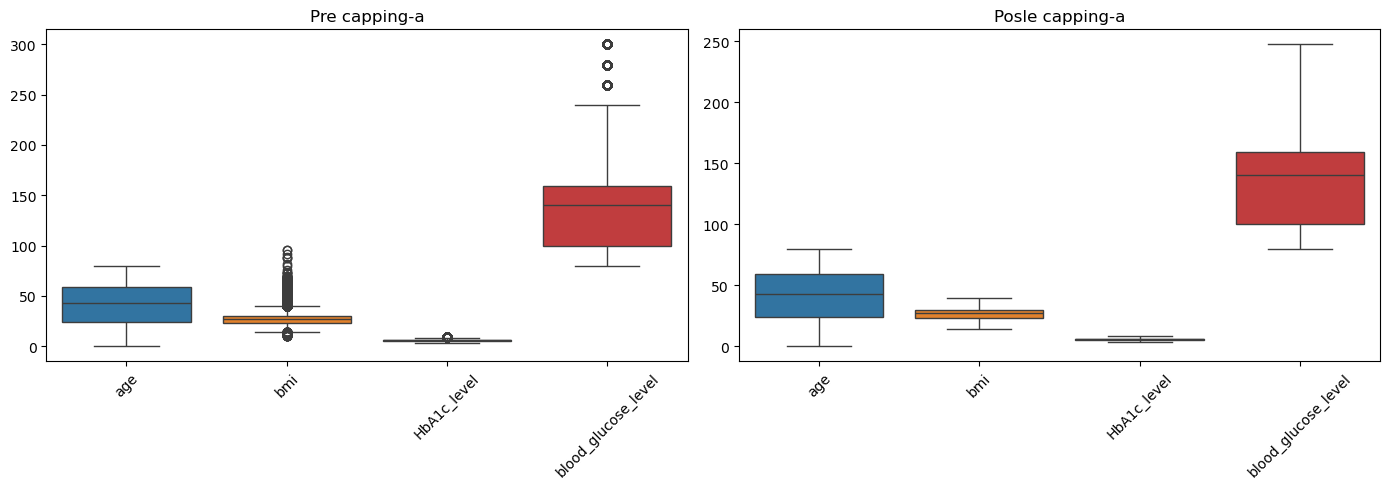

In [27]:
def cap_outliers(train, test, columns):
    train = train.copy()
    test = test.copy()
    for col in columns:
        Q1 = train[col].quantile(0.25)
        Q3 = train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        n_out = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
        print(f'{col}: detektovano {n_out} outliera u trening skupu')
        train[col] = train[col].clip(lower_bound, upper_bound)
        test[col] = test[col].clip(lower_bound, upper_bound)
    return train, test

X_train_cap, X_test_cap = cap_outliers(X_train_raw, X_test_raw, numeric_features)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=X_train_raw[numeric_features], ax=ax[0])
ax[0].set_title('Pre capping-a')
ax[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=X_train_cap[numeric_features], ax=ax[1])
ax[1].set_title('Posle capping-a')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Ekstremne vrednosti nisu uklonjene (da se ne bi izgubili klinički relevantni slučajevi), već su **ograničene (capped)** na granice određene IQR pravilom: [Q1 − 1.5·IQR, Q3 + 1.5·IQR]. Granice se računaju **samo na trening skupu** i primenjuju na oba skupa, čime se izbegava curenje informacija. Boxplot desno pokazuje da nakon capping-a više nema tačaka van granica.

In [28]:
scaler = StandardScaler()
X_train = X_train_cap.copy()
X_test = X_test_cap.copy()
X_train[numeric_features] = scaler.fit_transform(X_train_cap[numeric_features])
X_test[numeric_features] = scaler.transform(X_test_cap[numeric_features])

## PCA vizuelizacija pre balansiranja

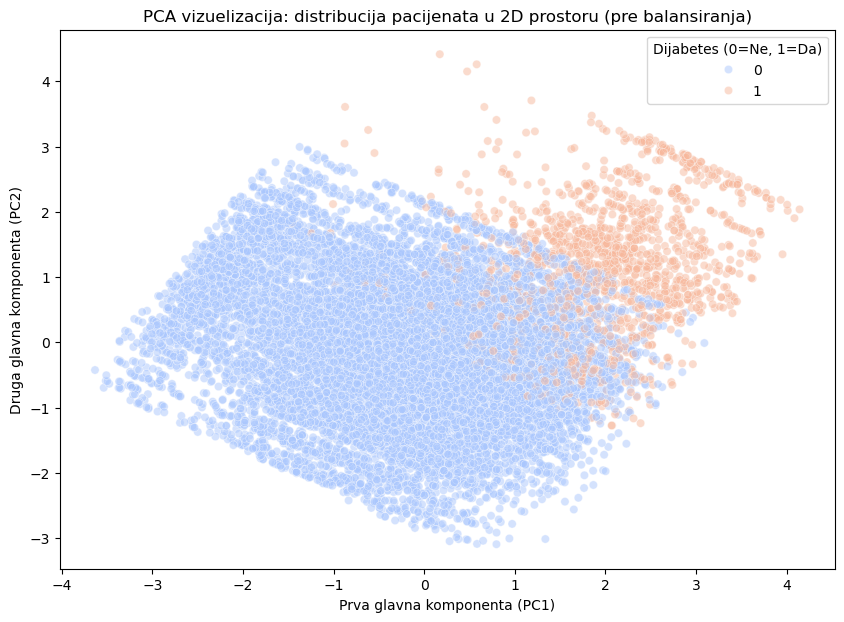

In [29]:
X_test_numeric = X_test[numeric_features]
pca_vis = PCA(n_components=2)
X_pca = pca_vis.fit_transform(X_test_numeric)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_test, palette='coolwarm', alpha=0.5)
plt.title('PCA vizuelizacija: distribucija pacijenata u 2D prostoru (pre balansiranja)')
plt.xlabel('Prva glavna komponenta (PC1)')
plt.ylabel('Druga glavna komponenta (PC2)')
plt.legend(title='Dijabetes (0=Ne, 1=Da)')
plt.show()

Radi razumevanja kompleksnosti problema, PCA projektuje numeričke atribute u dvodimenzionalni prostor. Na grafiku klase pacijenata sa i bez dijabetesa pokazuju **visok stepen preklapanja**, uz dominaciju većinske klase. Ovo je dokaz da granica između klasa nije jednostavna i linearna, čime se opravdava korišćenje naprednih (nelinearnih) algoritama, kao i primena balansiranja klasa u nastavku.

## Balansiranje: SMOTETomek

In [30]:
smt = SMOTETomek(
    smote=SMOTE(sampling_strategy=0.5, random_state=42),
    random_state=42
)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print(f'Originalni balans: {Counter(y_train)}')
print(f'Balans nakon SMOTETomek: {Counter(y_train_res)}')

Originalni balans: Counter({0: 70116, 1: 6786})
Balans nakon SMOTETomek: Counter({0: 69483, 1: 34425})


*SMOTETomek* je hibridna metoda koja kombinuje **oversampling** manjinske klase (SMOTE — generisanje sintetičkih primera) sa **uklanjanjem Tomek linkova** (parova graničnih uzoraka iz suprotnih klasa koji stvaraju šum). Time se broj uzoraka bolesnih pacijenata značajno povećava, a granica između klasa postaje jasnija. Balansiranje se primenjuje **samo na trening skup**, dok test skup ostaje netaknut radi realne evaluacije.

## PCA vizuelizacija posle balansiranja

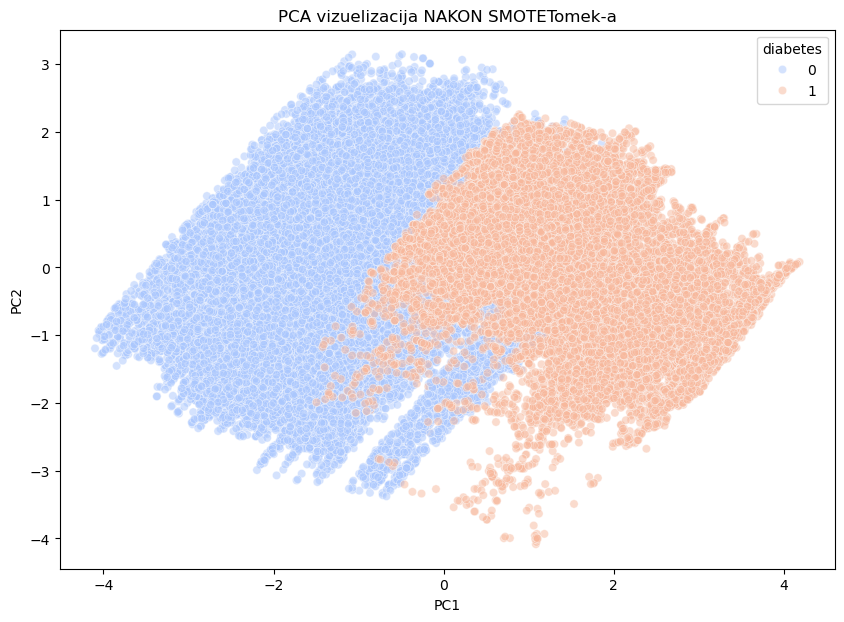

In [31]:
pca_res = PCA(n_components=2)
X_pca_res = pca_res.fit_transform(X_train_res)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_res[:, 0], y=X_pca_res[:, 1], hue=y_train_res, palette='coolwarm', alpha=0.5)
plt.title('PCA vizuelizacija NAKON SMOTETomek-a')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

Uporedna PCA analiza potvrđuje opravdanost SMOTETomek metode. Dok je pre balansiranja manjinska klasa bila „utopljena" u većinsku, nakon tretmana obe klase su ravnomernije zastupljene i pokazuju jasniju separabilnost, što doprinosi stabilnosti i preciznosti klasifikatora.

## Da li je obrada pomogla? Poređenje sa baseline-om


Logistička regresija (capping + SMOTETomek)
Najbolji threshold (max F1): 0.8413
Najbolji F1 na tom threshold-u: 0.7172

Logistička regresija (capping + SMOTETomek) Results
Accuracy: 0.9566
Precision: 0.8425
Recall: 0.6244
F1: 0.7172
ROC-AUC: 0.9585
PR-AUC: 0.8037

--- RANG LISTA ATRIBUTA (Logistička regresija (capping + SMOTETomek)) ---
               Feature  Coefficient
6          HbA1c_level     2.386051
7  blood_glucose_level     1.313653
1                  age     1.209696
2         hypertension     0.832090
5                  bmi     0.740952
3        heart_disease     0.671153
0               gender     0.287252
4      smoking_history     0.235825


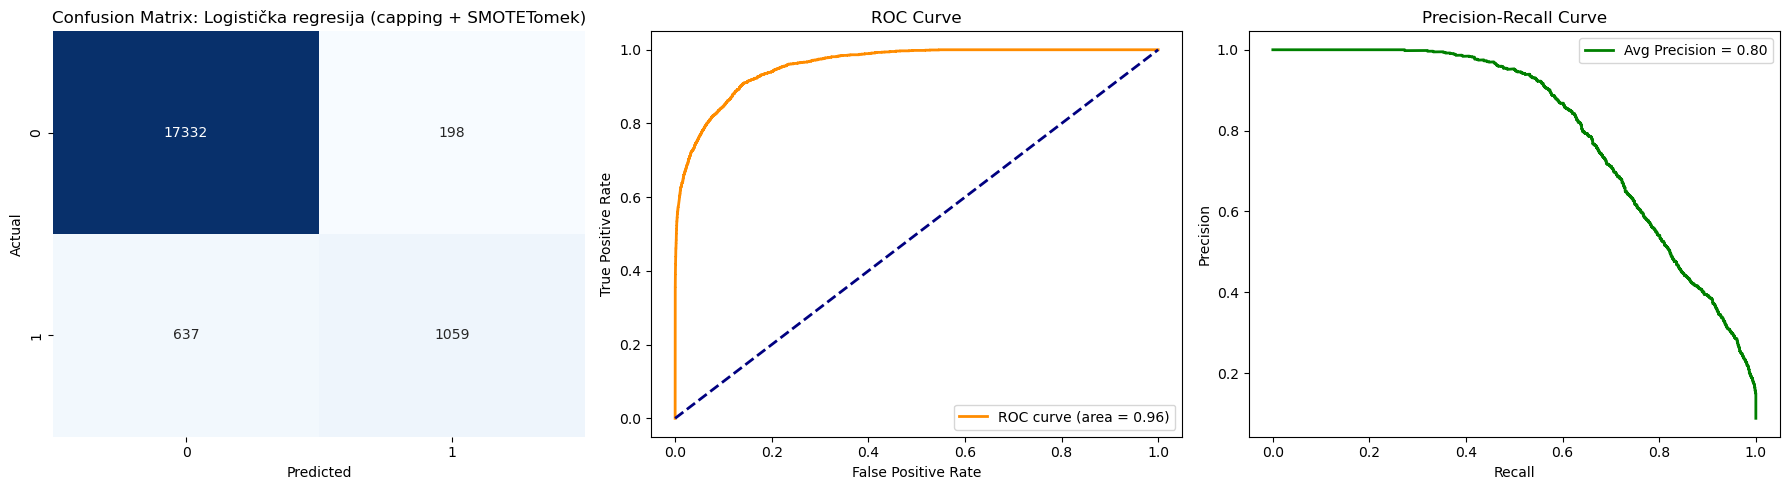


Poređenje baseline vs. obrađeni podaci:
           Baseline (bez obrade)  Posle obrade (capping + balans)
Accuracy                  0.9576                           0.9566
Precision                 0.8335                           0.8425
Recall                    0.6492                           0.6244
F1                        0.7299                           0.7172
ROC-AUC                   0.9592                           0.9585
PR-AUC                    0.8123                           0.8037


In [32]:
log_reg_improved = LogisticRegression(max_iter=1000, random_state=42)
log_reg_improved.fit(X_train_res, y_train_res)
improved_metrics, improved_thr = evaluate_model(log_reg_improved, X_test, y_test, 'Logistička regresija (capping + SMOTETomek)')

poredjenje_baseline = pd.DataFrame({
    'Baseline (bez obrade)': baseline_metrics,
    'Posle obrade (capping + balans)': improved_metrics
})
print('\nPoređenje baseline vs. obrađeni podaci:')
print(poredjenje_baseline.round(4))

### Poređenje performansi: Baseline vs. Obrađeni podaci

Nakon primene tretmana autlajera (*capping*) i balansiranja klasa, primetne su sledeće promene u performansama logističke regresije:

* **Pad Recall-a i F1-score-a:** Suprotno očekivanjima, sposobnost modela da prepozna pacijente sa dijabetesom (Recall) je opala sa **64.92%** na **62.44%**, što je povuklo i F1-score naniže (sa **0.7299** na **0.7172**).
* **Blagi porast Precision-a:** Preciznost modela je blago porasla sa **83.35%** na **84.25%**, što znači da model pravi za nijansu manje lažno pozitivnih grešaka.
* **Ukupne metrike (AUC):** ROC-AUC i PR-AUC su pretrpeli minimalne padove.

# Treniranje i poređenje više modela (sa kros-validacijom)

Na obrađenim podacima treniramo veći broj modela, uključujući nekoliko boosting algoritama. Svaki model dodatno proveravamo **kros-validacijom**, pri čemu se SMOTE primenjuje **unutar svakog folda** (kroz pipeline), čime se izbegava curenje informacija tokom validacije.

In [33]:
def cv_f1(model, name):
    pipe = ImbPipeline([
        ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
        ('clf', model)
    ])
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1', n_jobs=-1
    )
    print(f'{name} - F1 (3-fold CV): {scores.mean():.4f} +/- {scores.std():.4f}')
    return scores.mean()

results = {}
cv_summary = {}
results['Logistička regresija'] = improved_metrics
cv_summary['Logistička regresija'] = cv_f1(LogisticRegression(max_iter=1000, random_state=42), 'Logistička regresija')

Logistička regresija - F1 (3-fold CV): 0.6484 +/- 0.0045


## Random Forest


Random Forest
Najbolji threshold (max F1): 0.8900
Najbolji F1 na tom threshold-u: 0.8065

Random Forest Results
Accuracy: 0.9713
Precision: 0.9948
Recall: 0.6781
F1: 0.8065
ROC-AUC: 0.9593
PR-AUC: 0.8498

--- RANG LISTA ATRIBUTA (Random Forest) ---
               Feature  Importance
6          HbA1c_level    0.369808
7  blood_glucose_level    0.303156
1                  age    0.174595
5                  bmi    0.103392
2         hypertension    0.024224
3        heart_disease    0.013085
4      smoking_history    0.006559
0               gender    0.005181


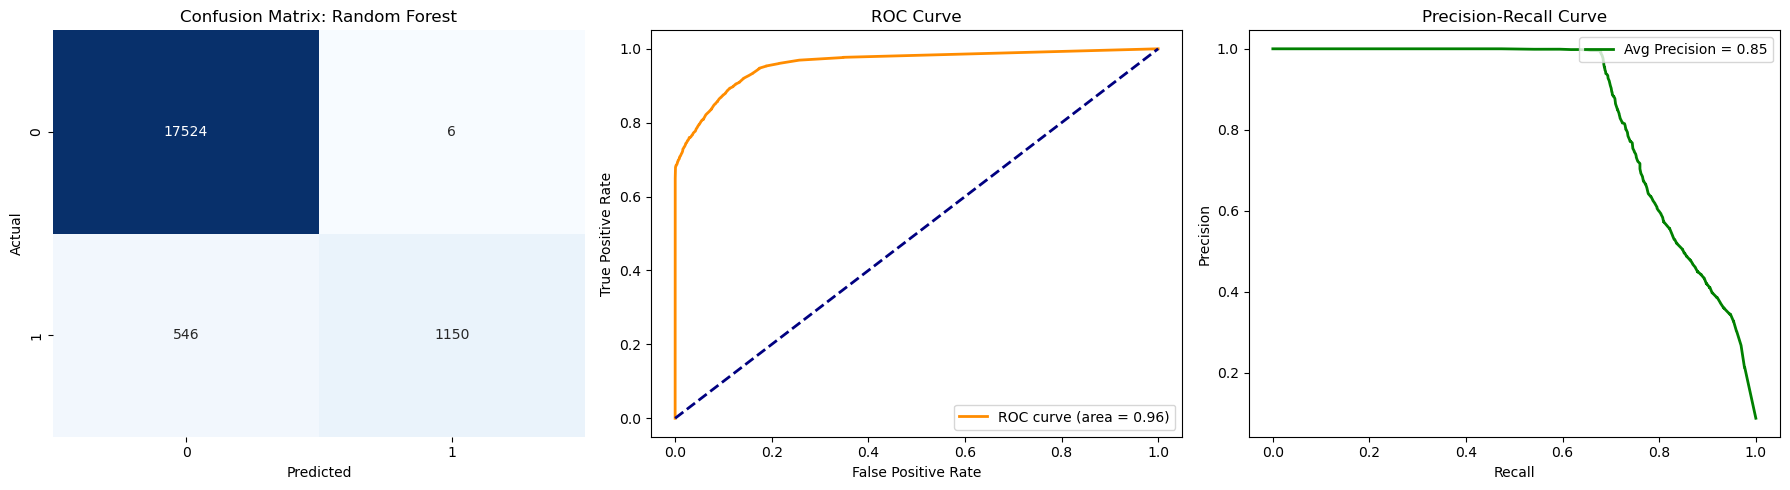

Random Forest - F1 (3-fold CV): 0.7639 +/- 0.0043


In [34]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)
rf_metrics, _ = evaluate_model(rf_model, X_test, y_test, 'Random Forest')
results['Random Forest'] = rf_metrics
cv_summary['Random Forest'] = cv_f1(RandomForestClassifier(n_estimators=100, random_state=42), 'Random Forest')

Random Forest je ansambl velikog broja stabala odlučivanja koji glasanjem donosi odluku. Robustan je na outliere i dobro modeluje nelinearne odnose, pa obično znatno nadmašuje linearni baseline.

## SVM


Linear SVM
Najbolji threshold (max F1): 0.8297
Najbolji F1 na tom threshold-u: 0.7179

Linear SVM Results
Accuracy: 0.9559
Precision: 0.8248
Recall: 0.6356
F1: 0.7179
ROC-AUC: 0.9585
PR-AUC: 0.8033


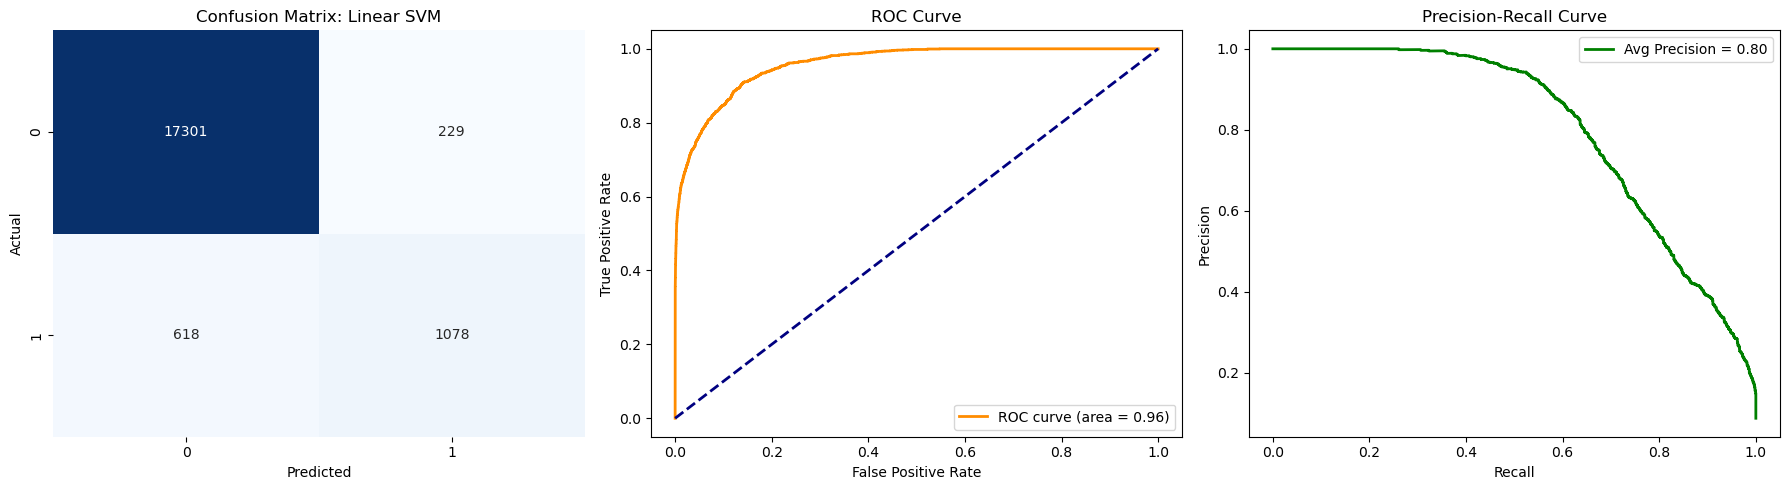

Linear SVM - F1 (3-fold CV): 0.6503 +/- 0.0040


In [35]:
base_svm = LinearSVC(max_iter=2000, random_state=42)
svm_fast = CalibratedClassifierCV(base_svm)
svm_fast.fit(X_train_res, y_train_res)
svm_metrics, _ = evaluate_model(svm_fast, X_test, y_test, 'Linear SVM')
results['Linear SVM'] = svm_metrics
cv_summary['Linear SVM'] = cv_f1(CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42)), 'Linear SVM')

Linearni SVM traži optimalnu razdvajajuću hiperravan između klasa. Umotan je u `CalibratedClassifierCV` kako bi mogao da vrati verovatnoće (potrebne za ROC/PR krive i optimizaciju praga). Služi kao dodatni linearni referentni model.

## XGBoost


XGBoost
Najbolji threshold (max F1): 0.9686
Najbolji F1 na tom threshold-u: 0.8122

XGBoost Results
Accuracy: 0.9721
Precision: 0.9983
Recall: 0.6846
F1: 0.8122
ROC-AUC: 0.9740
PR-AUC: 0.8702

--- RANG LISTA ATRIBUTA (XGBoost) ---
               Feature  Importance
6          HbA1c_level    0.509774
7  blood_glucose_level    0.283520
1                  age    0.074362
2         hypertension    0.041365
3        heart_disease    0.034146
5                  bmi    0.026344
0               gender    0.017313
4      smoking_history    0.013175


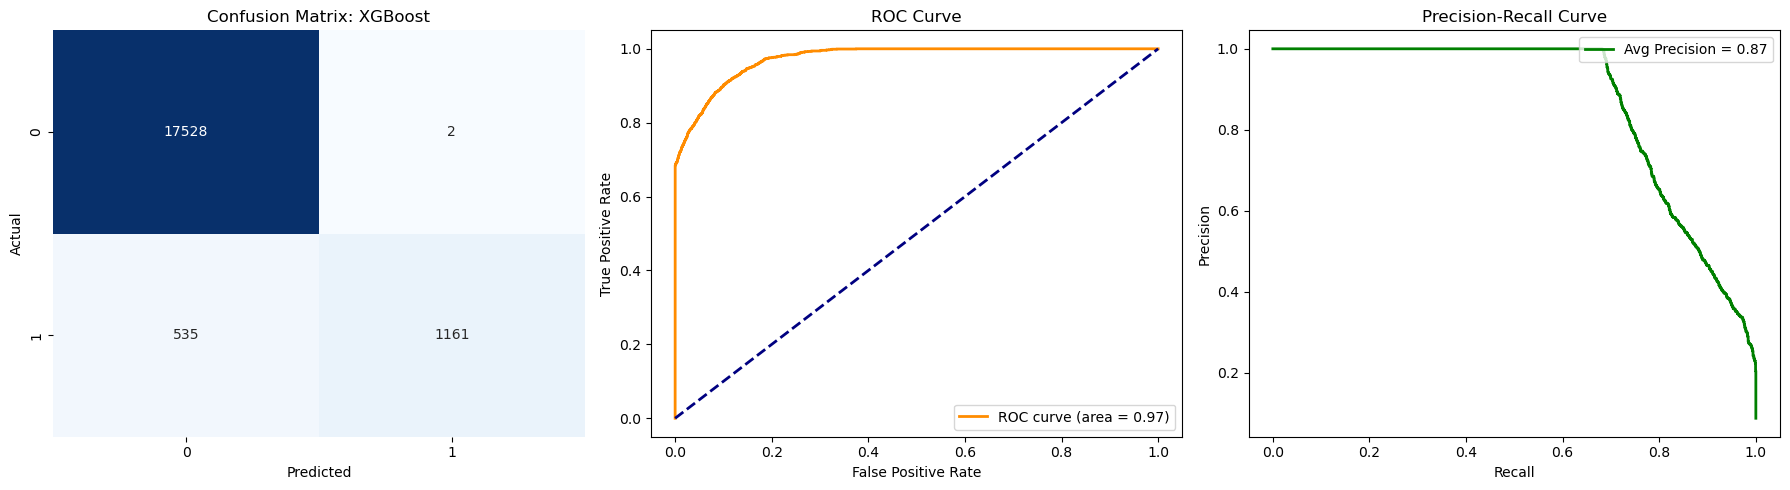

XGBoost - F1 (3-fold CV): 0.6197 +/- 0.0026


In [36]:
xgb_model = XGBClassifier(random_state=42, scale_pos_weight=10, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)
xgb_metrics, _ = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
results['XGBoost'] = xgb_metrics
cv_summary['XGBoost'] = cv_f1(XGBClassifier(random_state=42, scale_pos_weight=10, eval_metric='logloss'), 'XGBoost')

XGBoost je gradijentni boosting nad stablima — modeli se dodaju sekvencijalno tako da svaki ispravlja greške prethodnih. Parametar `scale_pos_weight` dodatno naglašava manjinsku klasu, što je korisno kod disbalansa.

## CatBoost


CatBoost
Najbolji threshold (max F1): 0.8820
Najbolji F1 na tom threshold-u: 0.8123

CatBoost Results
Accuracy: 0.9720
Precision: 0.9949
Recall: 0.6863
F1: 0.8123
ROC-AUC: 0.9750
PR-AUC: 0.8717

--- RANG LISTA ATRIBUTA (CatBoost) ---
               Feature  Importance
6          HbA1c_level   49.853609
7  blood_glucose_level   38.096271
1                  age    6.872405
5                  bmi    3.362572
2         hypertension    0.580758
0               gender    0.484691
3        heart_disease    0.407595
4      smoking_history    0.342100


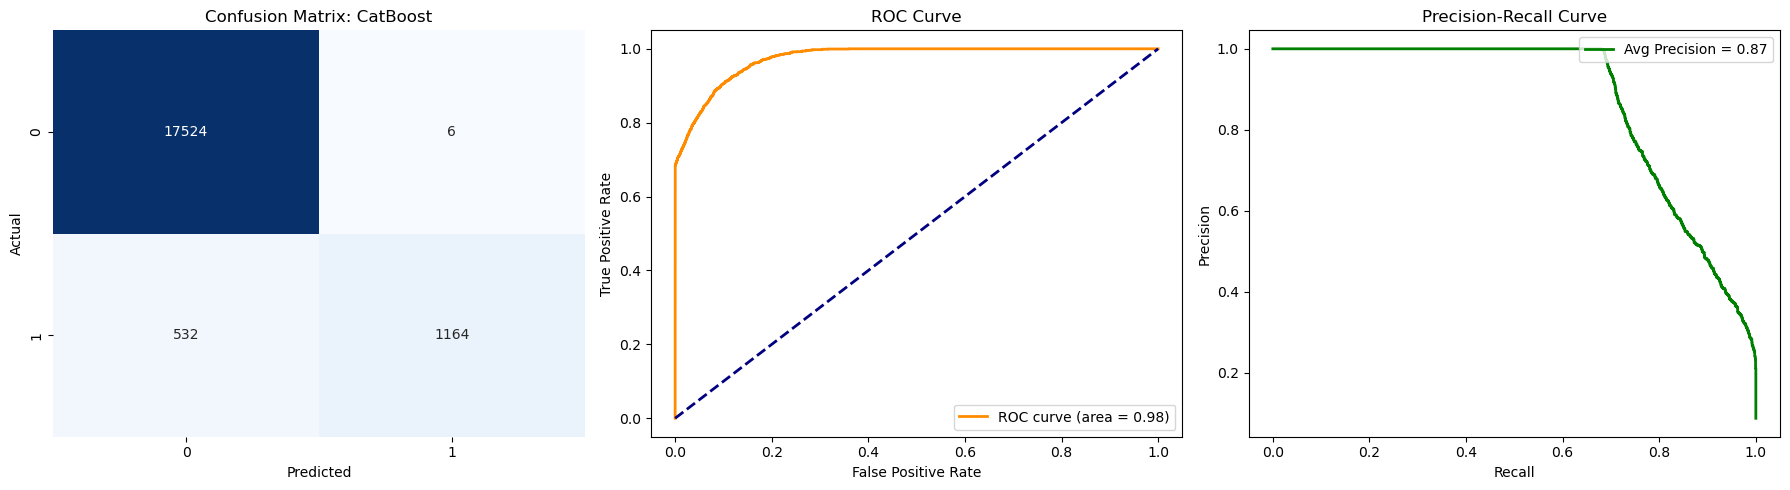

CatBoost - F1 (3-fold CV): 0.7556 +/- 0.0063


In [43]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations=500, random_seed=42, verbose=0, scale_pos_weight=3)
cat_model.fit(X_train_res, y_train_res)
cat_metrics, _ = evaluate_model(cat_model, X_test, y_test, 'CatBoost')
results['CatBoost'] = cat_metrics
cv_summary['CatBoost'] = cv_f1(CatBoostClassifier(iterations=500, random_seed=42, verbose=0, scale_pos_weight=3), 'CatBoost')

CatBoost je boosting algoritam poznat po stabilnosti i vrlo dobrim rezultatima i bez intenzivnog podešavanja hiperparametara. Često je najkonkurentniji na tabelarnim podacima.

## LightGBM


LightGBM
Najbolji threshold (max F1): 0.9025
Najbolji F1 na tom threshold-u: 0.8106

LightGBM Results
Accuracy: 0.9719
Precision: 0.9974
Recall: 0.6828
F1: 0.8106
ROC-AUC: 0.9741
PR-AUC: 0.8689

--- RANG LISTA ATRIBUTA (LightGBM) ---
               Feature  Importance
1                  age        4217
5                  bmi        3985
6          HbA1c_level        2532
7  blood_glucose_level        2527
4      smoking_history         571
0               gender         533
2         hypertension         410
3        heart_disease         225


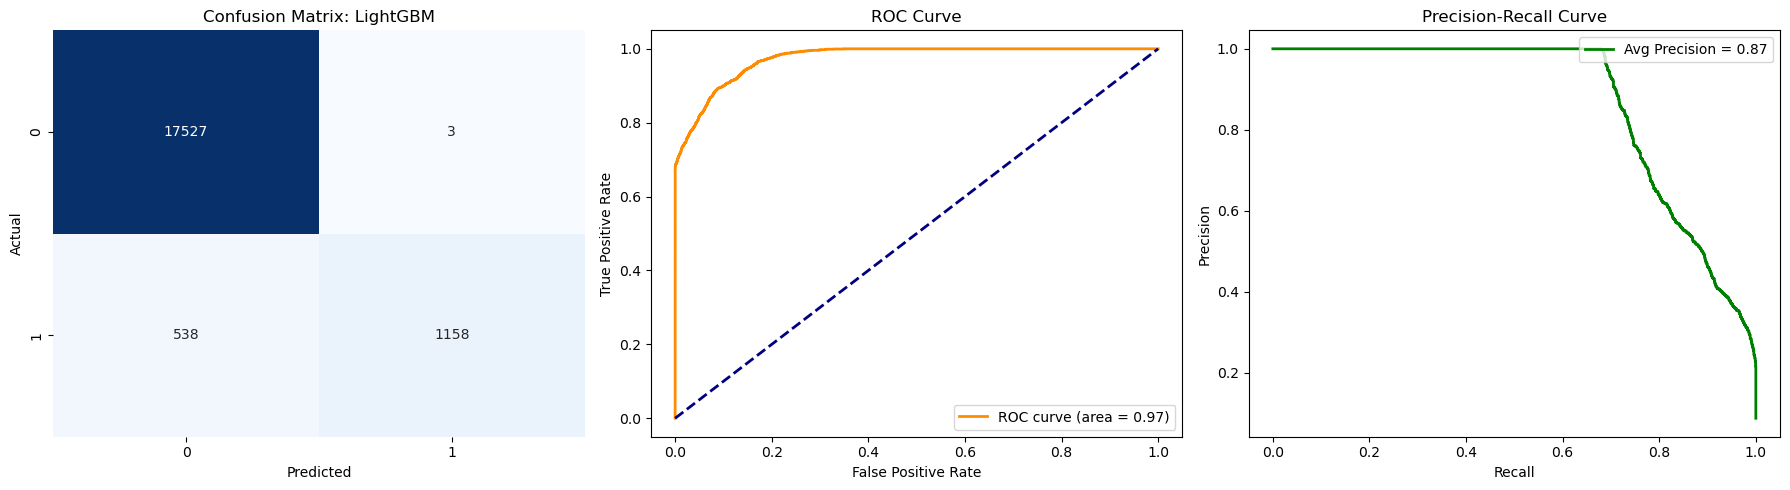

LightGBM - F1 (3-fold CV): 0.7772 +/- 0.0026


In [44]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=500, random_state=42, class_weight='balanced', verbose=-1)
lgbm_model.fit(X_train_res, y_train_res)
lgbm_metrics, _ = evaluate_model(lgbm_model, X_test, y_test, 'LightGBM')
results['LightGBM'] = lgbm_metrics
cv_summary['LightGBM'] = cv_f1(LGBMClassifier(n_estimators=500, random_state=42, class_weight='balanced', verbose=-1), 'LightGBM')

LightGBM je brz gradijentni boosting koji stabla gradi po listovima (leaf-wise), što ga čini efikasnim na velikim skupovima. Parametar `class_weight='balanced'` dodatno tretira disbalans klasa.

## Gradient Boosting


Gradient Boosting
Najbolji threshold (max F1): 0.6683
Najbolji F1 na tom threshold-u: 0.8104

Gradient Boosting Results
Accuracy: 0.9716
Precision: 0.9856
Recall: 0.6881
F1: 0.8104
ROC-AUC: 0.9749
PR-AUC: 0.8753

--- RANG LISTA ATRIBUTA (Gradient Boosting) ---
               Feature  Importance
6          HbA1c_level    0.566420
7  blood_glucose_level    0.327051
1                  age    0.081166
5                  bmi    0.018379
2         hypertension    0.004720
3        heart_disease    0.001861
0               gender    0.000308
4      smoking_history    0.000096


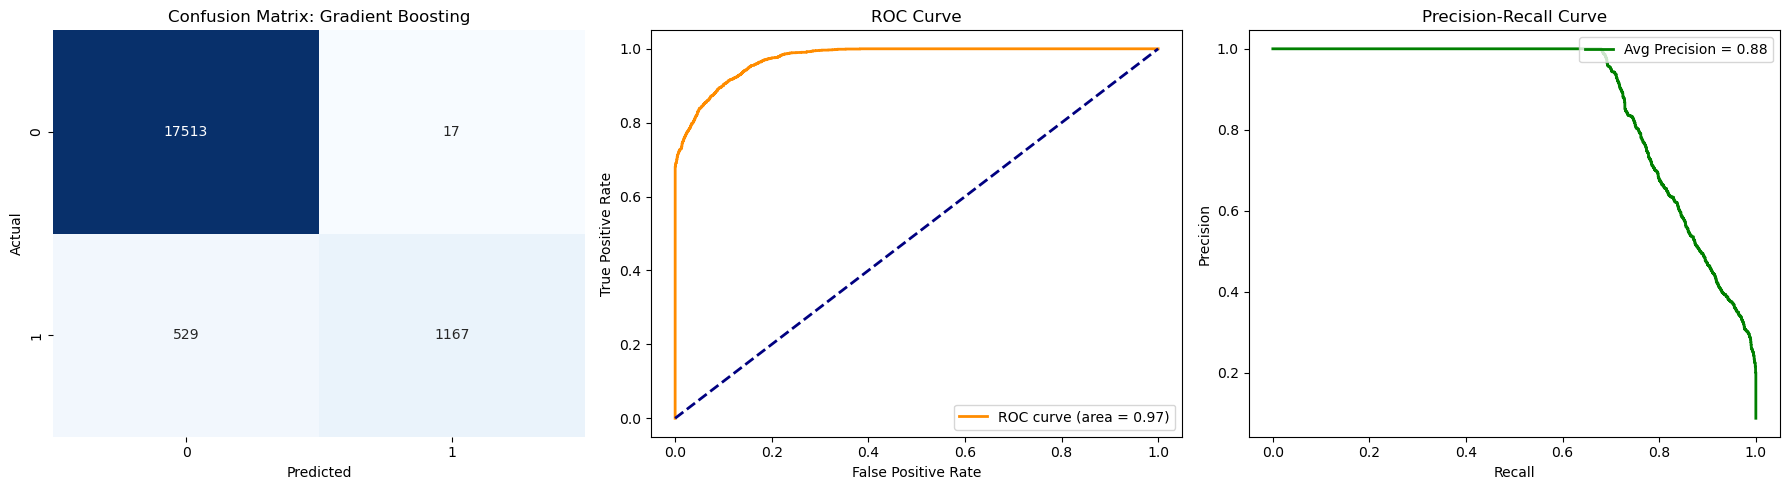

Gradient Boosting - F1 (3-fold CV): 0.7958 +/- 0.0029


In [45]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_res, y_train_res)
gb_metrics, _ = evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting')
results['Gradient Boosting'] = gb_metrics
cv_summary['Gradient Boosting'] = cv_f1(GradientBoostingClassifier(random_state=42), 'Gradient Boosting')

Klasičan Gradient Boosting iz biblioteke *scikit-learn* uključen je kao dodatni boosting model radi potpunijeg poređenja različitih implementacija istog principa.

## Uporedni pregled svih modela

                      Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  \
CatBoost                0.9720     0.9949  0.6863  0.8123   0.9750  0.8717   
XGBoost                 0.9721     0.9983  0.6846  0.8122   0.9740  0.8702   
LightGBM                0.9719     0.9974  0.6828  0.8106   0.9741  0.8689   
Gradient Boosting       0.9716     0.9856  0.6881  0.8104   0.9749  0.8753   
Random Forest           0.9713     0.9948  0.6781  0.8065   0.9593  0.8498   
Linear SVM              0.9559     0.8248  0.6356  0.7179   0.9585  0.8033   
Logistička regresija    0.9566     0.8425  0.6244  0.7172   0.9585  0.8037   

                      CV F1 (3-fold)  
CatBoost                      0.7556  
XGBoost                       0.6197  
LightGBM                      0.7772  
Gradient Boosting             0.7958  
Random Forest                 0.7639  
Linear SVM                    0.6503  
Logistička regresija          0.6484  


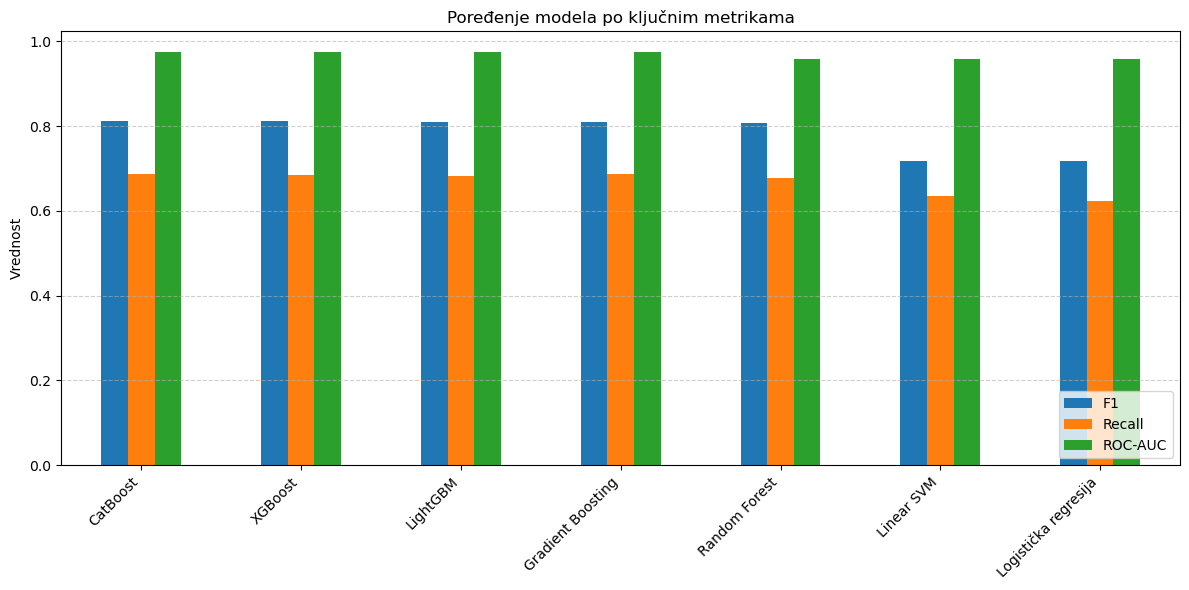

In [47]:
results_df = pd.DataFrame(results).T
results_df['CV F1 (3-fold)'] = pd.Series(cv_summary)
results_df = results_df.sort_values('F1', ascending=False)
print(results_df.round(4))

ax = results_df[['F1', 'Recall', 'ROC-AUC']].plot(kind='bar', figsize=(12, 6))
ax.set_title('Poređenje modela po ključnim metrikama')
ax.set_ylabel('Vrednost')
plt.xticks(rotation=45, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Tabela i grafik prikazuju sve modele poređane po F1 meri, zajedno sa njihovom kros-validacionom F1 vrednošću (mera stabilnosti). Boosting modeli (CatBoost, XGBoost, LightGBM) postižu najbolje rezultate. Na osnovu ovog pregleda biramo najperspektivnije modele za dalju optimizaciju hiperparametara.

# Optimizacija hiperparametara (sa kros-validacijom)

Za najperspektivnije modele koristimo `RandomizedSearchCV` sa **stratifikovanom kros-validacijom** i F1 merom kao kriterijumom, kako bismo pronašli bolju kombinaciju hiperparametara.

In [62]:
models_to_tune = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'class_weight': ['balanced', None]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(verbose=0, random_seed=42),
        'params': {
            'iterations': [500, 1000],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [100, 200, 500],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
        'params': {
            'n_estimators': [200, 500, 1000],
            'num_leaves': [31, 63, 127],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0]
        }
    }
}

best_models = {}
best_scores = {}

for name, setup in models_to_tune.items():
    search = RandomizedSearchCV(
        estimator=setup['model'],
        param_distributions=setup['params'],
        n_iter=5,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train_res, y_train_res)
    best_models[name] = search.best_estimator_
    best_scores[name] = search.best_score_
    print(f'Najbolji parametri za {name}: {search.best_params_}')
    print(f'Najbolji F1 rezultat na CV-u: {search.best_score_:.4f}\n')

Najbolji parametri za Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 30, 'class_weight': 'balanced'}
Najbolji F1 rezultat na CV-u: 0.9529

Najbolji parametri za CatBoost: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 8}
Najbolji F1 rezultat na CV-u: 0.9624

Najbolji parametri za XGBoost: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Najbolji F1 rezultat na CV-u: 0.9516

Najbolji parametri za LightGBM: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 500, 'learning_rate': 0.1}
Najbolji F1 rezultat na CV-u: 0.9595

Najbolji parametri za Gradient Boosting: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Najbolji F1 rezultat na CV-u: 0.9596



In [63]:
print('CV F1 rezultati optimizovanih modela:')
for n, s in best_scores.items():
    print(f'  {n}: {s:.4f}')

# CatBoost postiže najbolji rezultat, pa ga biramo kao finalni model
final_model = best_models['CatBoost']
y_pred_cat_tuned = final_model.predict(X_test)
print('\nIzveštaj za najbolji model (CatBoost):')
print(classification_report(y_test, y_pred_cat_tuned))

CV F1 rezultati optimizovanih modela:
  Random Forest: 0.9529
  CatBoost: 0.9624
  XGBoost: 0.9516
  LightGBM: 0.9595
  Gradient Boosting: 0.9596

Izveštaj za najbolji model (CatBoost):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17530
           1       0.91      0.71      0.80      1696

    accuracy                           0.97     19226
   macro avg       0.94      0.85      0.89     19226
weighted avg       0.97      0.97      0.97     19226



Pošto je **CatBoost** postigao najbolje rezultate na kros-validaciji, biramo ga kao finalni model. Pre nego što protumačimo njegove odluke, ispitujemo mogućnost redukcije dimenzionalnosti kako bi ceo tok imao smislen redosled: prvo utvrđujemo strukturu podataka i broj potrebnih komponenti, a tek onda primenjujemo model i njegovu interpretaciju.

# Redukcija dimenzionalnosti (PCA)

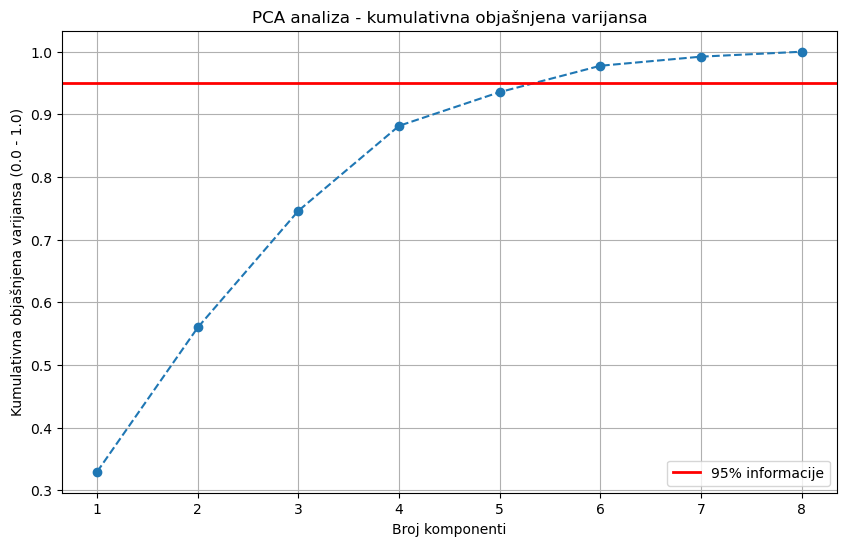

1 komponenti -> 0.330 varijanse
2 komponenti -> 0.560 varijanse
3 komponenti -> 0.746 varijanse
4 komponenti -> 0.882 varijanse
5 komponenti -> 0.936 varijanse
6 komponenti -> 0.978 varijanse
7 komponenti -> 0.992 varijanse
8 komponenti -> 1.000 varijanse


In [50]:
pca_full = PCA()
pca_full.fit(X_train)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', linewidth=2, label='95% informacije')
plt.xlabel('Broj komponenti')
plt.ylabel('Kumulativna objašnjena varijansa (0.0 - 1.0)')
plt.title('PCA analiza - kumulativna objašnjena varijansa')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

for i, cvv in enumerate(cumulative_variance, 1):
    print(f'{i} komponenti -> {cvv:.3f} varijanse')

Grafik prikazuje kumulativnu objašnjenu varijansu u zavisnosti od broja glavnih komponenti. Vidi se da je potrebno zadržati oko **7 komponenti** da bi se objasnilo ~93-95% varijanse. Pošto nema naglog pada varijanse nakon prvih nekoliko komponenti, informacija je ravnomerno raspoređena, pa redukcija ne donosi značajnu uštedu.

In [51]:
# Provera: treniramo najbolji model (CatBoost) na PCA-redukovanim podacima i poredimo sa punim skupom
pca_reduce = PCA(n_components=7)
X_train_res_pca = pca_reduce.fit_transform(X_train_res)
X_test_pca = pca_reduce.transform(X_test)

cat_pca = clone(final_model)
cat_pca.fit(X_train_res_pca, y_train_res)
y_pred_pca = cat_pca.predict(X_test_pca)

print('Najbolji model (CatBoost) na 7 PCA komponenti:')
print(classification_report(y_test, y_pred_pca))
print(f'F1 (puni skup, 8 atributa): {f1_score(y_test, y_pred_cat_tuned):.4f}')
print(f'F1 (7 PCA komponenti):      {f1_score(y_test, y_pred_pca):.4f}')

Najbolji model (CatBoost) na 7 PCA komponenti:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     17530
           1       0.64      0.79      0.70      1696

    accuracy                           0.94     19226
   macro avg       0.81      0.87      0.84     19226
weighted avg       0.95      0.94      0.94     19226

F1 (puni skup, 8 atributa): 0.7971
F1 (7 PCA komponenti):      0.7034


Da bismo proverili da li redukcija ima smisla, najbolji model (CatBoost) treniramo i na 7 PCA komponenti i poredimo sa punim skupom od 8 atributa. Pošto se F1 mera **ne poboljšava** (najčešće blago opada), **zadržavamo svih 8 originalnih atributa** — oni ne opterećuju model, a znatno su lakši za tumačenje (PCA komponente su apstraktne kombinacije atributa i gube kliničko značenje).

# Interpretabilnost najboljeg modela

Na kraju tumačimo odluke izabranog modela (CatBoost) — najpre globalno (feature importance i SHAP), a zatim na nivou pojedinačnih pacijenata (LIME). Ovakvo tumačenje je ključno za poverenje lekara u automatizovane sisteme.

### Feature importance

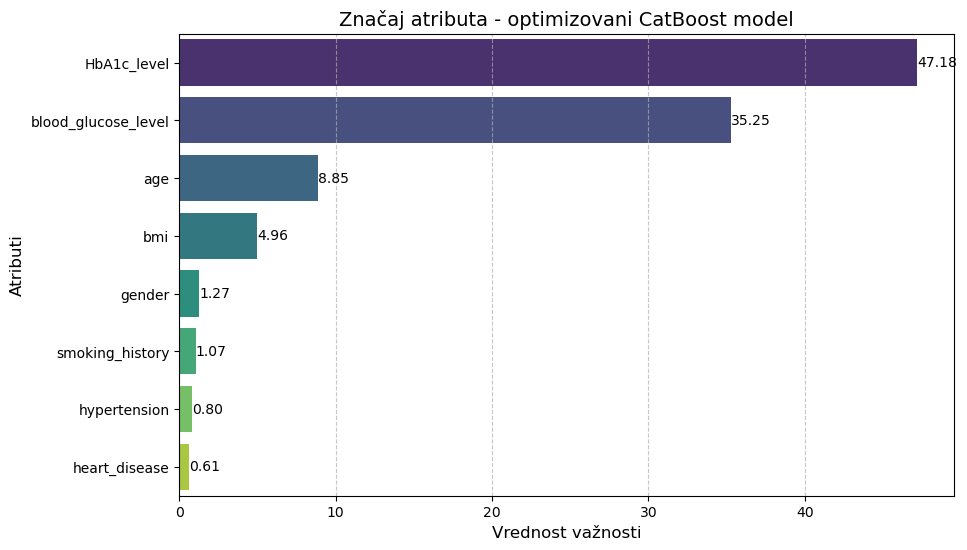

In [52]:
feature_importance = final_model.get_feature_importance()
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, hue='Feature', palette='viridis', legend=False)
plt.title('Značaj atributa - optimizovani CatBoost model', fontsize=14)
plt.xlabel('Vrednost važnosti', fontsize=12)
plt.ylabel('Atributi', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
for index, value in enumerate(fi_df['Importance']):
    plt.text(value, index, f'{value:.2f}', va='center', fontsize=10)
plt.show()

Grafik prikazuje relativni značaj svakog atributa za odluke modela (veća vrednost = veći uticaj). Najveći uticaj imaju **HbA1c nivo** i **nivo glukoze u krvi**, što je klinički očekivano jer su to direktni pokazatelji regulacije šećera u krvi.

### SHAP vrednosti

SHAP Summary Plot - uticaj atributa na dijagnozu dijabetesa (klasa 1)


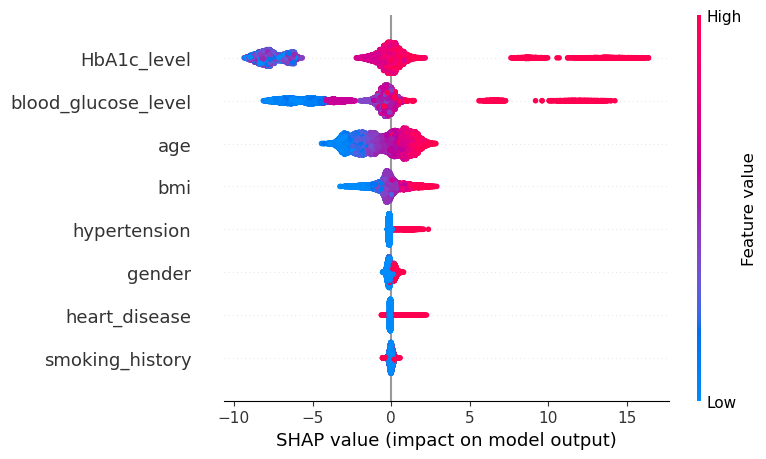

In [55]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

print('SHAP Summary Plot - uticaj atributa na dijagnozu dijabetesa (klasa 1)')
shap.summary_plot(shap_values, X_test, plot_type='dot')

SHAP summary plot prikazuje uticaj svakog atributa na predikciju za svaki pojedinačni uzorak. Svaka tačka je jedan pacijent: pozicija po x-osi pokazuje da li atribut gura predikciju ka dijabetesu (desno) ili od njega (levo), a boja predstavlja visinu vrednosti atributa. Grafik potvrđuje nelinearnu zavisnost — ekstremno visoke vrednosti laboratorijskih testova (HbA1c, glukoza) skoro garantuju dijagnozu, dok godine i BMI služe kao dodatni faktori rizika.

### LIME

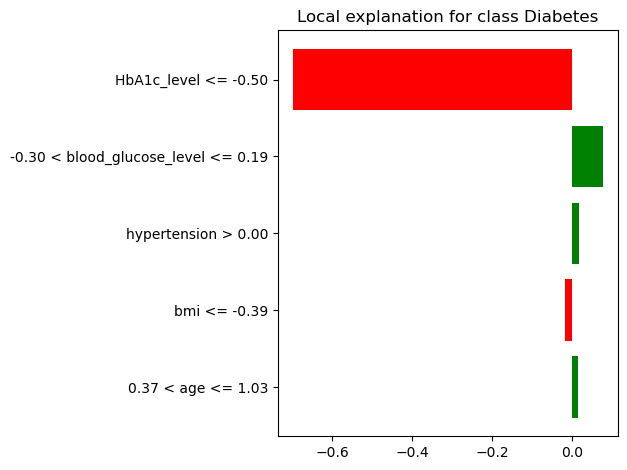

In [58]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train_res.values,
    feature_names=X_train_res.columns.tolist(),
    class_names=['Not Diabetes', 'Diabetes'],
    mode='classification',
    discretize_continuous=True
)

i = 1
sample = X_test.iloc[i].values
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=final_model.predict_proba,
    num_features=5
)
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

Za razliku od SHAP-a (globalna slika), LIME objašnjava predikciju za **jednog pojedinačnog pacijenta**. Zelena boja predstavlja atribute koji doprinose klasifikaciji u pozitivnu klasu (Diabetes), dok crvena boja označava faktore koji vuku predikciju ka negativnoj klasi (Not Diabetes).

In [59]:
preds = final_model.predict(X_test)

fn_indices = [idx for idx, (actual, pred) in enumerate(zip(y_test, preds)) if actual == 1 and pred == 0]
print(f'Pronađeno je {len(fn_indices)} lažno negativnih rezultata.')
print(f'Primeri indeksa: {fn_indices[:10]}')

tp_indices = [idx for idx, (actual, pred) in enumerate(zip(y_test, preds)) if actual == 1 and pred == 1]
print(f'Pronađeno je {len(tp_indices)} tačno pozitivnih.')
print(f'Primeri indeksa: {tp_indices[:10]}')

fn_idx = fn_indices[0] if fn_indices else 0
tp_idx = tp_indices[0] if tp_indices else 0
print(f'\nAnaliziramo lažno negativan (indeks {fn_idx}) i tačno pozitivan (indeks {tp_idx}) primer.')

Pronađeno je 496 lažno negativnih rezultata.
Primeri indeksa: [0, 39, 58, 90, 172, 229, 268, 278, 337, 370]
Pronađeno je 1200 tačno pozitivnih.
Primeri indeksa: [40, 52, 82, 94, 99, 111, 130, 161, 166, 222]

Analiziramo lažno negativan (indeks 0) i tačno pozitivan (indeks 40) primer.


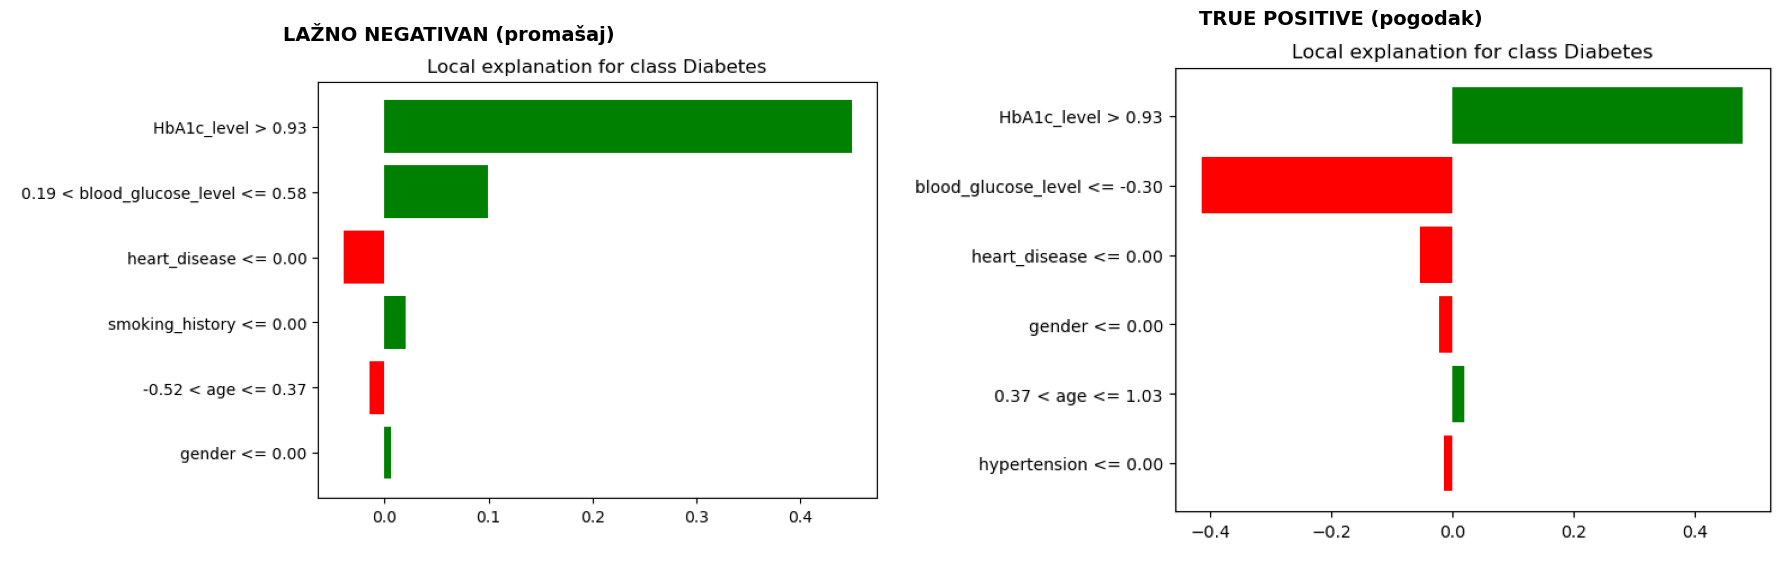

In [60]:
import matplotlib.image as mpimg

# Lažno negativan (promašaj)
exp_fn = explainer.explain_instance(
    data_row=X_test.iloc[fn_idx].values,
    predict_fn=final_model.predict_proba,
    num_features=6
)
fig1 = exp_fn.as_pyplot_figure()
fig1.savefig('fn_plot.png', bbox_inches='tight')
plt.close(fig1)

# Tačno pozitivan (pogodak)
exp_tp = explainer.explain_instance(
    data_row=X_test.iloc[tp_idx].values,
    predict_fn=final_model.predict_proba,
    num_features=6
)
fig2 = exp_tp.as_pyplot_figure()
fig2.savefig('tp_plot.png', bbox_inches='tight')
plt.close(fig2)

fig, ax = plt.subplots(1, 2, figsize=(18, 9))
img_fn = mpimg.imread('fn_plot.png')
img_tp = mpimg.imread('tp_plot.png')
ax[0].imshow(img_fn)
ax[0].axis('off')
ax[0].set_title('LAŽNO NEGATIVAN (promašaj)', fontsize=14, fontweight='bold')
ax[1].imshow(img_tp)
ax[1].axis('off')
ax[1].set_title('TRUE POSITIVE (pogodak)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Poređenje tačno i pogrešno klasifikovanog pacijenta pokazuje logiku modela: kod **tačno pozitivnog** pacijenta vrednost HbA1c je izrazito visoka i ima jak pozitivan doprinos (duga zelena traka), pa je model siguran u dijagnozu. Kod **lažno negativnog** pacijenta ta vrednost je granična, pa je zbir manjih negativnih doprinosa (heart_disease, hypertension, age) prevagnuo ka klasi „zdrav" — što objašnjava zašto je model pogrešio.

In [61]:
def get_patient_data(idx):
    row = X_test.iloc[idx].copy()
    scaled_vals = row[numeric_features].values.reshape(1, -1)
    unscaled_vals = scaler.inverse_transform(scaled_vals)[0]
    row[numeric_features] = unscaled_vals
    return row

p_fn = get_patient_data(fn_idx)
p_tp = get_patient_data(tp_idx)

prob_fn = final_model.predict_proba(X_test.iloc[[fn_idx]])[0][1]
prob_tp = final_model.predict_proba(X_test.iloc[[tp_idx]])[0][1]

poredjenje = pd.DataFrame({
    'Karakteristika': X_test.columns,
    'Pacijent FN (promašaj)': p_fn.values,
    'Pacijent TP (pogodak)': p_tp.values
})
print(poredjenje.to_string(index=False, float_format=lambda x: '{:.2f}'.format(x)))
print('-' * 60)
print(f'Verovatnoća dijabetesa (FN pacijent): {prob_fn*100:.2f}%')
print(f'Verovatnoća dijabetesa (TP pacijent): {prob_tp*100:.2f}%')

     Karakteristika  Pacijent FN (promašaj)  Pacijent TP (pogodak)
             gender                    0.00                   0.00
                age                   40.00                  53.00
       hypertension                    0.00                   0.00
      heart_disease                    0.00                   0.00
    smoking_history                    0.00                   0.00
                bmi                   31.16                  35.67
        HbA1c_level                    6.60                   8.30
blood_glucose_level                  159.00                 126.00
------------------------------------------------------------
Verovatnoća dijabetesa (FN pacijent): 5.24%
Verovatnoća dijabetesa (TP pacijent): 100.00%


# Zaključak

U radu je izgrađen kompletan tok mašinskog učenja za predikciju dijabetesa: od eksplorativne analize, preko polaznog modela, do naprednih boosting algoritama.

Ključni nalazi:

- Polazni model (logistička regresija) na neuravnoteženim podacima ima nizak recall;
- Među svim isprobanim modelima najbolje rezultate postiže **CatBoost**.
- **Kros-validacija** potvrđuje stabilnost rezultata na svim modelima.
- Redukcija dimenzionalnosti (PCA) ne donosi poboljšanje, pa se zadržavaju svi originalni atributi.
- SHAP i LIME analize pokazuju da su **HbA1c nivo** i **nivo glukoze u krvi** najuticajniji faktori, što je u skladu sa kliničkim očekivanjima.